In [1]:
import sys
import os
from pathlib import Path

# Find repo root
repo_root = Path('.').resolve()
for _ in range(5):
    if (repo_root / 'src').is_dir():
        repo_root = f"{repo_root}/src"
        break
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

print(f"Repo root: {repo_root}")

from datetime import datetime
from pprint import pprint
from skysat import skysat_v2
from shared_utils import s3utils
import json

Repo root: /home/jovyan/disasters-product-algorithms/src


In [ ]:
s3utils.retrieve_s3_file_list("csdap-planet-skysat-delivery", "disasters")

In [ ]:
s3utils.retrieve_s3_valid_dates("csdap-planet-skysat-delivery", "disasters")

In [2]:
tifs = skysat_v2.retrieve_skysat_resources(datetime(2026, 7, 18, 5, 21, 34))

Selected SkySat folder: disasters/marianas_landslide/c136997b-6919-4f61-98ef-bd2bcee1bae2
TIF files found: 364
   disasters/marianas_landslide/c136997b-6919-4f61-98ef-bd2bcee1bae2/20260714_221039_ssc1_u0001_analytic.tif
   disasters/marianas_landslide/c136997b-6919-4f61-98ef-bd2bcee1bae2/20260714_221039_ssc1_u0001_visual.tif
   disasters/marianas_landslide/c136997b-6919-4f61-98ef-bd2bcee1bae2/20260714_221039_ssc1_u0002_analytic.tif
   disasters/marianas_landslide/c136997b-6919-4f61-98ef-bd2bcee1bae2/20260714_221039_ssc1_u0002_visual.tif
   disasters/marianas_landslide/c136997b-6919-4f61-98ef-bd2bcee1bae2/20260714_221039_ssc1d1_0001_analytic.tif
   disasters/marianas_landslide/c136997b-6919-4f61-98ef-bd2bcee1bae2/20260714_221039_ssc1d1_0001_basic_analytic.tif
   disasters/marianas_landslide/c136997b-6919-4f61-98ef-bd2bcee1bae2/20260714_221039_ssc1d1_0001_visual.tif
   disasters/marianas_landslide/c136997b-6919-4f61-98ef-bd2bcee1bae2/20260714_221039_ssc1d1_0002_analytic.tif
   disasters/

In [3]:
toa_ndvi = sfc_ndvi = toa_evi = sfc_evi = toa_ndwi = sfc_ndwi = toa_truecolor = sfc_truecolor = toa_colorir = sfc_colorir = None

In [4]:
toa_ndvi = skysat_v2.calc_ndvi(tifs, "toa")

Analytic file found, proceeding
Generating NDVI
  ✔ Extracted reflectance coefficients: [3.3770798337795004e-05, 3.708707664640821e-05, 4.265132043104193e-05, 6.0308334360792335e-05]
  [!] UDM file not found for the selected date and source. Skipping mask step.
  Loaded & converted 2 bands from: /tmp/s3_temp/20260714_221039_ssc1_u0001_analytic.tif
  NDVI   → min: -0.7122  max:  0.8266  mean:  0.0909  median: -0.0003  valid px: 540,118,192
Generation completed, file saved to /tmp/s3_temp/202607_SkySat_toa_NDVI_2026-07-14T22:10:39Z.tif


In [ ]:
sfc_ndvi = skysat_v2.calc_ndvi(tifs, "sfc")

In [ ]:
toa_evi = skysat_v2.calc_evi(tifs, "toa")

In [ ]:
sfc_evi = skysat_v2.calc_evi(tifs, "sfc")

In [ ]:
toa_ndwi = skysat_v2.calc_ndwi(tifs, "toa")

In [ ]:
sfc_ndwi = skysat_v2.calc_ndwi(tifs, "sfc")

In [ ]:
toa_truecolor = skysat_v2.produce_truecolor(tifs, "toa")

In [ ]:
sfc_truecolor = skysat_v2.produce_truecolor(tifs, "sfc")

In [ ]:
toa_colorir = skysat_v2.produce_colorir(tifs, "toa")

In [ ]:
sfc_colorir = skysat_v2.produce_colorir(tifs, "sfc")

Cogging and previewing /tmp/s3_temp/202607_SkySat_toa_NDVI_2026-07-14T22:10:39Z.tif
  Data type: float32
  No-data value: -9999
  Source CRS: EPSG:32655
  Compression: ZSTD (level 22)
  Overview levels: 5
  Creating COG: 202607_SkySat_toa_NDVI_2026-07-14T22:10:39Z.tif.cog.tmp.tif
  ✓ COG created: 202607_SkySat_toa_NDVI_2026-07-14T22:10:39Z.tif
/tmp/s3_temp/202607_SkySat_toa_NDVI_2026-07-14T22:10:39Z.tif


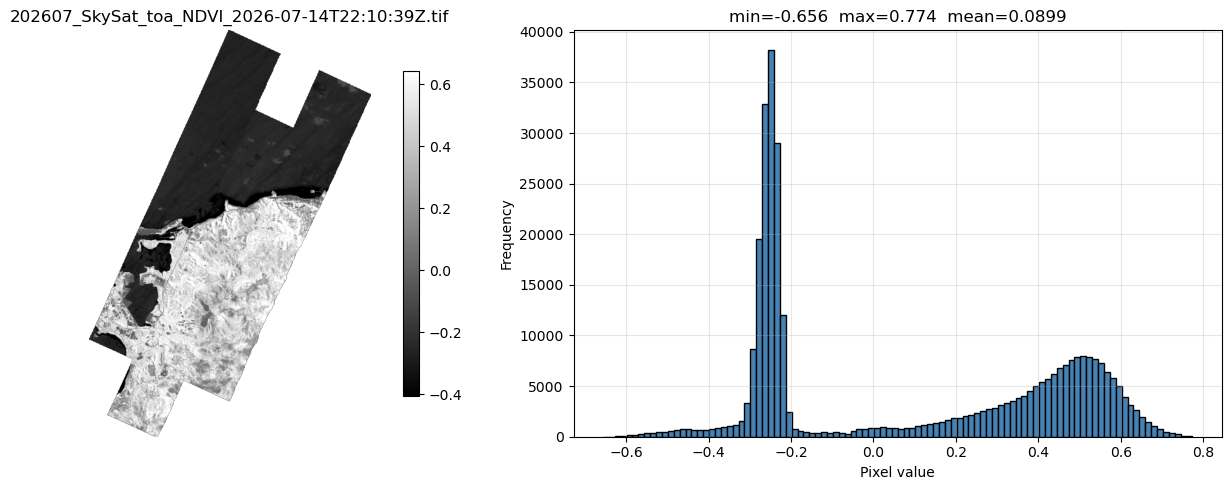

In [5]:
files = [toa_ndvi, sfc_ndvi, toa_evi, sfc_evi, toa_ndwi, sfc_ndwi, toa_truecolor, sfc_truecolor, toa_colorir, sfc_colorir]
no_data = [-9999, -9999, -9999, -9999, -9999, -9999, 0, 0, 0, 0]

from shared_utils.plotting import preview_cogs
from shared_utils.cog_utils import convert_to_cog

for file_id in range(len(files)):
    if files[file_id] is not None:
        print(f"Cogging and previewing {files[file_id]}")
        cog_path = convert_to_cog(
            files[file_id],
            nodata=no_data[file_id],
            compression="ZSTD",
            compression_level=22,
            dst_crs = None # Note that these files are not in WGS 84, but we're not converting them here.
        )
        print(cog_path)
        preview_cogs([cog_path], sample_n=4)

In [ ]:
s3utils.remove_s3_temp()